<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V17_AD_Improvements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V17 — Anomaly Detection Verbesserungen: Mannheim Testbed

**Ziel:** AD-Performance auf Mannheim verbessern, bevor Transfer gestartet wird.

## Experimente:
1. **Baseline LSTM-AE** (aus V16 repliziert, als Referenz)
2. **Z-normalisierter Threshold pro Stunde** — RE normalisieren nach Tageszeit
3. **Conv1D-LSTM-AE** — CNN-Schicht vor LSTM im Encoder
4. **LSTM Forecaster** — Seq2One Prediction statt Reconstruction
5. **Ensemble** — Kombination AE + StatPipeline Scores

### Alle Modelle werden gespeichert fuer spaetere Transfer-Experimente.

### V16-Erkenntnisse:
- point_spike: PR-AUC ~0.72, DR ~89% ✓
- collective: PR-AUC ~0.22, DR ~35% → verbesserbar
- **point_drop: PR-AUC ~0.004, DR ~1%** → kritisch
- **contextual: PR-AUC ~0.007, DR ~1%** → kritisch


In [1]:
# ══════════════════════════════════════════════════════════════
# 0a — Colab Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


In [2]:
# ══════════════════════════════════════════════════════════════
# 0b — Imports
# ══════════════════════════════════════════════════════════════
import os, math, json, random, warnings, time, re, glob, copy, pickle
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import poisson
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve,
    classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
print(f"TF {tf.__version__}, GPU: {tf.config.list_physical_devices('GPU')}")


TF 2.19.0, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ══════════════════════════════════════════════════════════════
# 0c — Config + Pfade
# ══════════════════════════════════════════════════════════════
DATA_BASE    = '/content/drive/MyDrive/BA_Colab/data'
CLEANED_BASE = '/content/drive/MyDrive/BA_Colab/cleaned'

RUN_NAME    = 'v17_ad_improvements'
RESULTS_DIR = f'{DATA_BASE}/{RUN_NAME}'
MODELS_DIR  = f'{RESULTS_DIR}/models'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Mannheim only
demand_path        = f'{CLEANED_BASE}/demand/Mannheim/demand_cleaned.parquet'
geo_path           = f'{CLEANED_BASE}/geo_information/geo_information.parquet'
station_names_path = f'{DATA_BASE}/station_names/station_names.parquet'

print(f"Results: {RESULTS_DIR}")
print(f"Models:  {MODELS_DIR}")


Results: /content/drive/MyDrive/BA_Colab/data/v17_ad_improvements
Models:  /content/drive/MyDrive/BA_Colab/data/v17_ad_improvements/models


---
## Shared Functions (aus V16 uebernommen)

In [4]:
# ══════════════════════════════════════════════════════════════
# 1 — Aggregation
# ══════════════════════════════════════════════════════════════
def aggregate_station_level(df: pd.DataFrame, minutes: int = 60,
                            add_relative: bool = False) -> pd.DataFrame:
    out = df.copy()
    freq = f"{minutes}min"
    out["time_bin"] = out["timestamp"].dt.floor(freq)

    agg = (
        out.groupby(
            ["station_id", "station_name_id", "station_name", "location_id", "time_bin"],
            as_index=False
        )
        .agg({
            "n_lends": "sum",
            "n_returns": "sum",
            "latitude": "first",
            "longitude": "first"
        })
        .rename(columns={"time_bin": "hour_ts"})
    )

    agg["total_demand"] = agg["n_lends"] + agg["n_returns"]
    agg["net_flow"] = agg["n_returns"] - agg["n_lends"]
    agg["abs_net_flow"] = agg["net_flow"].abs()

    agg["hour"] = agg["hour_ts"].dt.hour
    agg["dow"] = agg["hour_ts"].dt.dayofweek
    agg["month"] = agg["hour_ts"].dt.month
    agg["is_weekend"] = agg["dow"].isin([5, 6]).astype(int)

    agg["hour_sin"] = np.sin(2 * np.pi * agg["hour"] / 24)
    agg["hour_cos"] = np.cos(2 * np.pi * agg["hour"] / 24)
    agg["dow_sin"]  = np.sin(2 * np.pi * agg["dow"] / 7)
    agg["dow_cos"]  = np.cos(2 * np.pi * agg["dow"] / 7)
    agg["month_sin"] = np.sin(2 * np.pi * (agg["month"] - 1) / 12)
    agg["month_cos"] = np.cos(2 * np.pi * (agg["month"] - 1) / 12)

    agg = agg.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
    return agg


In [5]:
# ══════════════════════════════════════════════════════════════
# 2 — Gap-Fill
# ══════════════════════════════════════════════════════════════
def fill_missing_time_bins(x: pd.DataFrame, minutes: int = 60) -> pd.DataFrame:
    freq = f"{minutes}min"
    parts = []
    x = x.copy().sort_values(["station_id", "hour_ts"])
    x = (
        x.groupby(["station_id", "hour_ts"], as_index=False)
         .agg({
             "station_name_id": "first", "station_name": "first",
             "location_id": "first", "latitude": "first",
             "longitude": "first", "n_lends": "sum", "n_returns": "sum",
         })
    )
    key_cols = ["station_id", "station_name_id", "station_name",
                "location_id", "latitude", "longitude"]

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").copy()
        full_idx = pd.date_range(g["hour_ts"].min(), g["hour_ts"].max(), freq=freq)
        g = g.set_index("hour_ts").reindex(full_idx)
        g.index.name = "hour_ts"
        g["n_lends"]   = g["n_lends"].fillna(0).astype(int)
        g["n_returns"] = g["n_returns"].fillna(0).astype(int)
        for col in key_cols:
            g[col] = g[col].ffill().bfill()
        parts.append(g.reset_index())

    result = pd.concat(parts, ignore_index=True)
    result["total_demand"] = result["n_lends"] + result["n_returns"]
    result["net_flow"]     = result["n_returns"] - result["n_lends"]
    result["abs_net_flow"] = result["net_flow"].abs()

    result["hour"] = result["hour_ts"].dt.hour
    result["dow"]  = result["hour_ts"].dt.dayofweek
    result["month"] = result["hour_ts"].dt.month
    result["is_weekend"] = result["dow"].isin([5, 6]).astype(int)

    result["hour_sin"]  = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"]  = np.cos(2 * np.pi * result["hour"] / 24)
    result["dow_sin"]   = np.sin(2 * np.pi * result["dow"] / 7)
    result["dow_cos"]   = np.cos(2 * np.pi * result["dow"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)

    return result.sort_values(["station_id", "hour_ts"]).reset_index(drop=True)


In [6]:
# ══════════════════════════════════════════════════════════════
# 3 — Station-Filter, Demand-Regime, Train/Val/Test Split
# ══════════════════════════════════════════════════════════════
def prepare_stations_and_splits(df: pd.DataFrame, cfg, city_name=""):
    n_days = (df["hour_ts"].max() - df["hour_ts"].min()).days + 1
    min_events = int(n_days * cfg.min_events_per_day)

    station_volume = df.groupby("station_id")["total_demand"].sum()
    active_ids = station_volume[station_volume >= min_events].index.tolist()
    df = df[df["station_id"].isin(active_ids)].copy()

    station_profile = (
        df.groupby(["station_id", "station_name"], as_index=False)
          .agg(
              avg_total_demand_h=("total_demand", "mean"),
              avg_lends_h=("n_lends", "mean"),
              avg_returns_h=("n_returns", "mean"),
              latitude=("latitude", "first"),
              longitude=("longitude", "first")
          )
    )
    q1 = station_profile["avg_total_demand_h"].quantile(cfg.low_demand_q)
    q2 = station_profile["avg_total_demand_h"].quantile(cfg.high_demand_q)
    station_profile["demand_regime"] = station_profile["avg_total_demand_h"].apply(
        lambda x: "low" if x <= q1 else ("mid" if x <= q2 else "high")
    )
    df = df.merge(
        station_profile[["station_id", "demand_regime", "avg_total_demand_h"]],
        on="station_id", how="left"
    )

    t_min = df["hour_ts"].min()
    t_max = df["hour_ts"].max()
    total_h = (t_max - t_min).total_seconds() / 3600

    train_end = t_min + pd.Timedelta(hours=int(total_h * cfg.train_ratio))
    val_end   = t_min + pd.Timedelta(hours=int(total_h * cfg.val_ratio))

    cn = f" ({city_name})" if city_name else ""
    print(f"  Aktive Stationen{cn}: {df['station_id'].nunique()}")
    print(f"  Regime: {station_profile['demand_regime'].value_counts().to_dict()}")
    print(f"  Zeitraum: {t_min.date()} bis {t_max.date()} ({n_days} Tage)")
    print(f"  Split: Train < {train_end.date()}, Val < {val_end.date()}, Test ab {val_end.date()}")

    return df, station_profile, train_end, val_end


In [7]:
# ══════════════════════════════════════════════════════════════
# 4 — Rolling kontextuelle z-Scores
# ══════════════════════════════════════════════════════════════
TARGETS = ["n_lends", "n_returns", "net_flow", "total_demand"]
COUNT_TARGETS = ["n_lends", "n_returns", "total_demand"]

def add_context_keys(x: pd.DataFrame) -> pd.DataFrame:
    x = x.copy()
    x["ctx_hour"] = x["hour_ts"].dt.hour
    x["ctx_dow"]  = x["hour_ts"].dt.dayofweek
    return x

def rolling_context_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    mu_col    = f"{target}_mu_ctx_roll"
    sd_col    = f"{target}_sd_ctx_roll"
    score_col = f"{target}_z_ctx_roll"

    n_slots = max(rolling_days // 7, 4)
    main_window = n_slots
    main_minp   = min(min_obs, main_window)

    grouped = x.groupby(["station_id", "ctx_hour", "ctx_dow"])[target]
    rolling_mean = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).mean()
    )
    rolling_std = grouped.transform(
        lambda s: s.shift(1).rolling(window=main_window, min_periods=main_minp).std(ddof=0)
    )

    fb1_window = n_slots * 2
    fb1_minp   = min(min_obs, fb1_window)
    grouped_sh = x.groupby(["station_id", "ctx_hour"])[target]
    fb1_mean = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).mean()
    )
    fb1_std = grouped_sh.transform(
        lambda s: s.shift(1).rolling(window=fb1_window, min_periods=fb1_minp).std(ddof=0)
    )

    fb2_window = n_slots * 4
    fb2_minp   = min(min_obs, fb2_window)
    grouped_s = x.groupby(["station_id"])[target]
    fb2_mean = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).mean()
    )
    fb2_std = grouped_s.transform(
        lambda s: s.shift(1).rolling(window=fb2_window, min_periods=fb2_minp).std(ddof=0)
    )

    mu = rolling_mean.copy()
    sd = rolling_std.copy()
    mask1 = mu.isna()
    mu = mu.where(~mask1, fb1_mean)
    sd = sd.where(~mask1, fb1_std)
    mask2 = mu.isna()
    mu = mu.where(~mask2, fb2_mean)
    sd = sd.where(~mask2, fb2_std)

    sd = sd.clip(lower=1e-6)
    z = (x[target] - mu) / sd

    x[mu_col]    = mu
    x[sd_col]    = sd
    x[score_col] = z
    return x


In [8]:
# ══════════════════════════════════════════════════════════════
# 5 — Poisson-Tail-Scores
# ══════════════════════════════════════════════════════════════
def add_rolling_poisson_scores_vectorized(
    full_df: pd.DataFrame, target: str,
    rolling_days: int = 56, min_obs: int = 20
) -> pd.DataFrame:
    x = full_df.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)

    lam_col       = f"{target}_lambda_ctx_roll"
    score_col     = f"{target}_poisson_upper_score"
    score_low_col = f"{target}_poisson_lower_score"
    mu_col        = f"{target}_mu_ctx_roll"

    if mu_col not in x.columns:
        raise ValueError(f"{mu_col} muss zuerst berechnet werden")

    x[lam_col] = x[mu_col].clip(lower=1e-6)
    vals = x[target].values
    lams = x[lam_col].values

    with np.errstate(divide='ignore', invalid='ignore'):
        tail_p = poisson.sf(vals.astype(float) - 1, lams.astype(float))
        score  = -np.log10(np.clip(tail_p, 1e-12, None))
        lower_p   = poisson.cdf(vals.astype(float), lams.astype(float))
        score_low = -np.log10(np.clip(lower_p, 1e-12, None))

    mask_nan = np.isnan(lams)
    score[mask_nan]     = np.nan
    score_low[mask_nan] = np.nan

    x[score_col]     = score
    x[score_low_col] = score_low
    return x


In [9]:
# ══════════════════════════════════════════════════════════════
# 6 — ECDF-Kalibrierung + Labels
# ══════════════════════════════════════════════════════════════
def percentile_score(train_vals: np.ndarray, values: np.ndarray) -> np.ndarray:
    train_vals = np.asarray(train_vals, dtype=float)
    values     = np.asarray(values, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    if len(train_vals) == 0:
        return np.full(len(values), np.nan, dtype=float)
    train_sorted = np.sort(train_vals)
    ranks = np.searchsorted(train_sorted, values, side="right")
    return ranks / len(train_sorted)

def calibrate_scores_by_station(
    full_df: pd.DataFrame, train_mask: pd.Series, raw_score_cols: List[str]
) -> pd.DataFrame:
    x = full_df.copy()
    for col in raw_score_cols:
        if col not in x.columns:
            continue
        pct_col = f"{col}_pct_station"
        x[pct_col] = np.nan
        for sid, grp in x.groupby("station_id", sort=False):
            idx_all   = grp.index
            idx_train = grp.index[train_mask.loc[idx_all]]
            train_vals = x.loc[idx_train, col].to_numpy(dtype=float) if len(idx_train) > 0 else np.array([])
            vals       = x.loc[idx_all, col].to_numpy(dtype=float)
            x.loc[idx_all, pct_col] = percentile_score(train_vals, vals)
    return x

def build_eval_labels_calibrated(x: pd.DataFrame) -> pd.DataFrame:
    y = x.copy()
    y["label_eval"] = "normal"

    z_up = "total_demand_score_upper_pct_station"
    z_low = "total_demand_score_lower_pct_station"
    p_up  = "total_demand_poisson_upper_score_pct_station"
    p_low = "total_demand_poisson_lower_score_pct_station"

    required = [z_up, z_low, p_up, p_low]
    missing = [c for c in required if c not in y.columns]
    if missing:
        raise ValueError(f"Fehlende Spalten: {missing}")

    td = y["total_demand"].fillna(0)
    mu = y["total_demand_mu_ctx_roll"]

    abs_min_high    = np.maximum(5, np.ceil(mu + 2)).fillna(5)
    abs_min_low_ref = np.maximum(3, np.ceil(mu)).fillna(3)

    high_strong    = ((y[z_up] >= 0.995) | (y[p_up] >= 0.995)) & (td >= abs_min_high)
    high_consensus = ((y[z_up] >= 0.99) & (y[p_up] >= 0.99)) & (td >= abs_min_high)
    cond_high = high_strong | high_consensus

    low_possible  = mu >= abs_min_low_ref
    low_strong    = ((y[z_low] >= 0.999) | (y[p_low] >= 0.999)) & low_possible
    low_consensus = ((y[z_low] >= 0.995) & (y[p_low] >= 0.995)) & low_possible
    cond_low = (low_strong | low_consensus) & ~cond_high

    grau_high = ((y[z_up] >= 0.99) | (y[p_up] >= 0.99)) & ~cond_high & ~cond_low
    grau_low  = ((y[z_low] >= 0.99) | (y[p_low] >= 0.99)) & ~cond_high & ~cond_low & ~grau_high

    y.loc[grau_high, "label_eval"] = "grauzone_high"
    y.loc[grau_low,  "label_eval"] = "grauzone_low"
    y.loc[cond_high, "label_eval"] = "anomal_high"
    y.loc[cond_low,  "label_eval"] = "anomal_low"
    return y


In [10]:
# ══════════════════════════════════════════════════════════════
# 7 — Statistik-Pipeline
# ══════════════════════════════════════════════════════════════
def run_statistical_pipeline(df: pd.DataFrame, cfg, train_end):
    print("  [1/5] Kontext-Keys...")
    df = add_context_keys(df)

    print("  [2/5] Rolling z-Scores...")
    for tgt in TARGETS:
        df = rolling_context_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )
    for tgt in TARGETS:
        zc = f"{tgt}_z_ctx_roll"
        df[f"{tgt}_score_upper"] = df[zc]
        df[f"{tgt}_score_lower"] = -df[zc]

    print("  [3/5] Poisson-Tail-Scores...")
    for tgt in COUNT_TARGETS:
        df = add_rolling_poisson_scores_vectorized(
            df, target=tgt,
            rolling_days=cfg.rolling_days, min_obs=cfg.min_context_obs
        )

    print("  [4/5] ECDF-Kalibrierung...")
    raw_score_cols = []
    for tgt in TARGETS:
        raw_score_cols += [f"{tgt}_score_upper", f"{tgt}_score_lower"]
    for tgt in COUNT_TARGETS:
        raw_score_cols += [f"{tgt}_poisson_upper_score", f"{tgt}_poisson_lower_score"]

    train_mask = df["hour_ts"] < train_end
    df = calibrate_scores_by_station(df, train_mask, raw_score_cols)

    print("  [5/5] Labels...")
    df = build_eval_labels_calibrated(df)

    anomaly_rate = df["label_eval"].isin(["anomal_high", "anomal_low"]).mean()
    print(f"  Label-Verteilung:")
    print(f"    {df['label_eval'].value_counts().to_dict()}")
    print(f"    Anomalie-Rate: {anomaly_rate:.4f} ({anomaly_rate*100:.2f}%)")
    return df


In [11]:
# ══════════════════════════════════════════════════════════════
# 8 — Sequenzbuilder (Window-Level Labels)
# ══════════════════════════════════════════════════════════════
from numpy.lib.stride_tricks import sliding_window_view

def make_sequences_with_window_labels(
    x: pd.DataFrame, feature_cols: List[str], window_size: int,
    synth_label_col: str = "synth_label",
    synth_type_col: str = "synth_type",
    require_contiguous: bool = True,
    agg_minutes: int = 60
) -> Tuple[np.ndarray, pd.DataFrame]:
    X_parts, meta_parts = [], []
    expected_ns = pd.Timedelta(minutes=agg_minutes).value

    for sid, g in x.groupby("station_id", sort=False):
        g = g.sort_values("hour_ts").reset_index(drop=True)
        n = len(g)
        if n < window_size:
            continue

        vals = g[feature_cols].to_numpy(dtype=np.float32)
        win  = sliding_window_view(vals, window_shape=window_size, axis=0)
        win  = np.moveaxis(win, -1, 1)

        valid_mask = np.ones(n - window_size + 1, dtype=bool)

        if require_contiguous:
            ts_int = pd.to_datetime(g["hour_ts"]).astype("int64").to_numpy()
            diffs  = np.diff(ts_int)
            step_ok = (diffs == expected_ns).astype(np.int8)
            if window_size > 1:
                ok_sums = np.convolve(step_ok, np.ones(window_size-1, dtype=np.int32), mode="valid")
                valid_mask = (ok_sums == (window_size - 1))

        if not valid_mask.any():
            continue

        end_indices = np.arange(window_size - 1, n)[valid_mask]
        X_parts.append(win[valid_mask])

        meta_chunk = g.iloc[end_indices].copy()

        synth_arr = g[synth_label_col].to_numpy()
        type_arr  = g[synth_type_col].to_numpy()

        window_labels, window_types, window_counts = [], [], []
        for end_idx in end_indices:
            start_idx = end_idx - window_size + 1
            window_synth = synth_arr[start_idx:end_idx + 1]
            window_type  = type_arr[start_idx:end_idx + 1]

            has_synth = int(window_synth.max())
            n_synth   = int(window_synth.sum())

            if has_synth:
                synth_positions = np.where(window_synth == 1)[0]
                wtype = window_type[synth_positions[-1]]
            else:
                wtype = "none"

            window_labels.append(has_synth)
            window_types.append(wtype)
            window_counts.append(n_synth)

        meta_chunk["window_synth_label"] = window_labels
        meta_chunk["window_synth_type"]  = window_types
        meta_chunk["n_synth_in_window"]  = window_counts
        meta_parts.append(meta_chunk)

    if X_parts:
        X    = np.concatenate(X_parts, axis=0)
        meta = pd.concat(meta_parts, axis=0).reset_index(drop=True)
    else:
        X    = np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
        meta = pd.DataFrame()

    return X, meta


In [12]:
# ══════════════════════════════════════════════════════════════
# 9 — LSTM-AE Modell + Training (Baseline)
# ══════════════════════════════════════════════════════════════
def build_lstm_autoencoder(
    n_input_features: int,
    window_size: int,
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1,
    bidirectional: bool = False,
    n_output_features: Optional[int] = None,
) -> keras.Model:
    n_output_features = n_output_features or n_input_features

    inputs = keras.Input(shape=(window_size, n_input_features), name="encoder_input")
    x = inputs
    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        lstm = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"encoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"encoder_bi_{i+1}")(x) if bidirectional else lstm(x)

    latent = x
    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)

    for i in range(n_layers):
        lstm = layers.LSTM(
            latent_dim,
            return_sequences=True,
            dropout=dropout,
            name=f"decoder_lstm_{i+1}"
        )
        x = layers.Bidirectional(lstm, name=f"decoder_bi_{i+1}")(x) if bidirectional else lstm(x)

    outputs = layers.TimeDistributed(
        layers.Dense(n_output_features),
        name="output_dense"
    )(x)

    return keras.Model(inputs, outputs, name="lstm_autoencoder")


def train_model_generic(model, X_train, Y_train, X_val, Y_val,
                        epochs, lr, batch_size, early_stop, verbose=1):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
        loss="mse"
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=early_stop,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=4, verbose=1
        )
    ]
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )
    return model, history


In [13]:
# ══════════════════════════════════════════════════════════════
# 10 — AE Scoring Helpers
# ══════════════════════════════════════════════════════════════
def predict_in_batches(model, X, batch_size=2048):
    preds = []
    for i in range(0, len(X), batch_size):
        preds.append(model.predict(X[i:i + batch_size], verbose=0))
    return np.concatenate(preds, axis=0) if preds else np.empty((0, 0, 0), dtype=np.float32)

def compute_reconstruction_scores(X, X_hat, input_features, score_features,
                                  mode="last_step_mean"):
    """Compute reconstruction error scores."""
    score_idx = [input_features.index(c) for c in score_features]
    err = (X - X_hat) ** 2
    err_score = err[:, :, score_idx]

    if mode == "last_step_mean":
        return err_score[:, -1, :].mean(axis=1)
    elif mode == "window_mean":
        return err_score.mean(axis=(1, 2))
    elif mode == "max_over_features":
        # Max statt Mean -> verhindert Verwaesserung bei asymmetrischen Anomalien
        return err_score[:, -1, :].max(axis=1)
    else:
        raise ValueError(f"Unbekannter mode: {mode}")


In [14]:
# ══════════════════════════════════════════════════════════════
# 11 — Data loading helper
# ══════════════════════════════════════════════════════════════
def prepare_city_data(demand_path: str, geo_path: str, station_names_path: str,
                      cfg, city_name: str):
    print(f"\n{'='*70}")
    print(f"  DATEN-PIPELINE: {city_name}")
    print(f"{'='*70}")

    demand = pd.read_parquet(demand_path)
    geo    = pd.read_parquet(geo_path)
    snames = pd.read_parquet(station_names_path)
    snames = snames.rename(columns={'id': 'station_name_id', 'name': 'station_name'})

    demand = demand.merge(snames[['station_name_id', 'station_name']], on='station_name_id', how='left')
    demand = demand.merge(geo[['location_id', 'latitude', 'longitude']], on='location_id', how='left')

    demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True)

    print(f"  Roh: {len(demand):,} Zeilen, {demand['station_id'].nunique()} Stationen")
    print(f"  Zeitraum: {demand['timestamp'].min().date()} bis {demand['timestamp'].max().date()}")

    print("\n  [1] Aggregation...")
    df = aggregate_station_level(demand, minutes=cfg.aggregation_minutes)
    print(f"      Shape: {df.shape}")

    print("  [2] Gap-Fill...")
    n_before = len(df)
    df = fill_missing_time_bins(df, minutes=cfg.aggregation_minutes)
    print(f"      {n_before:,} -> {len(df):,} (+{len(df)-n_before:,})")

    print("  [3] Stationen, Regime, Splits...")
    df, station_profile, train_end, val_end = prepare_stations_and_splits(df, cfg, city_name)

    print("  [4] Statistische Scoring-Pipeline...")
    df = run_statistical_pipeline(df, cfg, train_end)

    return df, station_profile, train_end, val_end


In [15]:
# ══════════════════════════════════════════════════════════════
# 12 — Synthetic Injection (aus V16)
# ══════════════════════════════════════════════════════════════
INJECTION_SCENARIOS = {
    "balanced": {
        "desc": "Gleichverteilung ohne Collective-Dominanz",
        "probs": [0.35, 0.30, 0.25, 0.10],
        "collective_block_len": (2, 4),
    },
}

def inject_synthetic_anomalies(
    df: pd.DataFrame,
    test_start: pd.Timestamp,
    scenario: str = "balanced",
    injection_rate: float = 0.015,
    seed: int = 42,
    verbose: bool = True
) -> pd.DataFrame:
    scn = INJECTION_SCENARIOS[scenario]
    probs = scn["probs"]
    block_min, block_max = scn["collective_block_len"]

    rng = np.random.RandomState(seed)
    out = df.copy()

    out["original_n_lends"]   = out["n_lends"].copy()
    out["original_n_returns"] = out["n_returns"].copy()
    out["synth_label"] = 0
    out["synth_type"]  = "none"

    test_mask = out["hour_ts"] >= test_start
    test_idx  = out[test_mask].index.to_numpy()

    if len(test_idx) == 0:
        print("  WARNUNG: Keine Test-Daten!")
        return out

    n_inject = max(1, int(len(test_idx) * injection_rate))
    test_df = out.loc[test_idx]
    has_demand = test_df[test_df["total_demand"] > 0].index.to_numpy()

    if len(has_demand) < n_inject:
        n_inject = len(has_demand)

    inject_idx = rng.choice(has_demand, size=n_inject, replace=False)
    types = rng.choice(
        ["point_spike", "point_drop", "contextual", "collective"],
        size=n_inject, p=probs
    )

    injected_indices = set()

    for idx, anom_type in zip(inject_idx, types):
        if idx in injected_indices:
            continue

        row = out.loc[idx]

        if anom_type == "point_spike":
            factor = rng.uniform(3.0, 8.0)
            out.loc[idx, "n_lends"]   = int(row["n_lends"] * factor) + rng.randint(2, 10)
            out.loc[idx, "n_returns"] = int(row["n_returns"] * factor) + rng.randint(2, 10)
            out.loc[idx, "synth_label"] = 1
            out.loc[idx, "synth_type"]  = "point_spike"
            injected_indices.add(idx)

        elif anom_type == "point_drop":
            regime = row.get("demand_regime", "low")
            if regime == "high" and row["total_demand"] >= 8:
                do_drop = True
            elif regime == "mid" and row["total_demand"] >= 5:
                do_drop = True
            else:
                do_drop = False

            if do_drop:
                out.loc[idx, "n_lends"]   = rng.randint(0, 2)
                out.loc[idx, "n_returns"] = rng.randint(0, 2)
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"]  = "point_drop"
                injected_indices.add(idx)

        elif anom_type == "contextual":
            hour = row["hour_ts"].hour
            sid  = row["station_id"]

            same_station_test = out[
                (out["station_id"] == sid) & test_mask &
                (~out.index.isin(injected_indices))
            ]

            if hour in [7, 8, 9, 17, 18, 19]:
                contrast = same_station_test[same_station_test["hour_ts"].dt.hour.isin([1, 2, 3, 4])]
            else:
                contrast = same_station_test[same_station_test["hour_ts"].dt.hour.isin([8, 9, 17, 18])]

            if len(contrast) > 0:
                swap_idx = contrast.index[rng.randint(0, len(contrast))]
                out.loc[idx, "n_lends"]   = out.loc[swap_idx, "original_n_lends"]
                out.loc[idx, "n_returns"] = out.loc[swap_idx, "original_n_returns"]
                out.loc[idx, "synth_label"] = 1
                out.loc[idx, "synth_type"]  = "contextual"
                injected_indices.add(idx)

        elif anom_type == "collective":
            block_len = rng.randint(block_min, block_max + 1)
            sid = row["station_id"]
            station_test = out[
                (out["station_id"] == sid) & test_mask
            ].sort_values("hour_ts")

            if idx in station_test.index:
                pos = station_test.index.get_loc(idx)
                if pos + block_len <= len(station_test):
                    block_idx = station_test.index[pos:pos + block_len]
                    factor = rng.uniform(2.5, 5.0)
                    for bidx in block_idx:
                        if bidx not in injected_indices:
                            out.loc[bidx, "n_lends"]   = int(out.loc[bidx, "original_n_lends"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "n_returns"] = int(out.loc[bidx, "original_n_returns"] * factor) + rng.randint(1, 5)
                            out.loc[bidx, "synth_label"] = 1
                            out.loc[bidx, "synth_type"]  = "collective"
                            injected_indices.add(bidx)

    out["total_demand"]  = out["n_lends"] + out["n_returns"]
    out["net_flow"]      = out["n_returns"] - out["n_lends"]
    out["abs_net_flow"]  = out["net_flow"].abs()

    n_injected = out["synth_label"].sum()
    test_total = test_mask.sum()

    if verbose:
        print(f"\n  Synthetic Injection [{scenario}]:")
        print(f"    Test-Zeilen gesamt:  {test_total:,}")
        print(f"    Injizierte Punkte:   {n_injected:,} ({n_injected/test_total*100:.2f}%)")
        for t, c in out[out["synth_label"] == 1]["synth_type"].value_counts().items():
            print(f"      {t}: {c}")

    return out


---
## V17: Unified Evaluation Function

In [16]:
# ══════════════════════════════════════════════════════════════
# 13 — V17 Unified Evaluation
# ══════════════════════════════════════════════════════════════
def evaluate_v17(
    meta: pd.DataFrame,
    score_col: str,
    experiment_name: str,
    val_start: pd.Timestamp,
    test_start: pd.Timestamp,
    verbose: bool = True
) -> Dict:
    """
    Unified evaluation:
    - Threshold auf VAL (best F1)
    - Per-Type PR-AUC + DR auf TEST
    - Gibt Dict mit allen Metriken zurueck
    """
    meta = meta.copy()
    meta["split_eval"] = np.where(
        meta["hour_ts"] < val_start, "train",
        np.where(meta["hour_ts"] < test_start, "val", "test")
    )

    val_m  = meta[meta["split_eval"] == "val"].copy()
    test_m = meta[meta["split_eval"] == "test"].copy()

    if len(val_m) == 0 or len(test_m) == 0:
        print(f"  [{experiment_name}] WARNUNG: Keine VAL/TEST-Daten!")
        return {}

    results = {"experiment": experiment_name, "n_val": len(val_m), "n_test": len(test_m)}

    # --- VAL: Threshold bestimmen ---
    y_val = val_m["synth_label"].astype(int).values
    s_val = val_m[score_col].values

    threshold = None
    if len(np.unique(y_val)) > 1:
        prec_v, rec_v, thr_v = precision_recall_curve(y_val, s_val)
        results["val_pr_auc"] = average_precision_score(y_val, s_val)
        if len(thr_v) > 0:
            f1_v = 2 * prec_v[:-1] * rec_v[:-1] / (prec_v[:-1] + rec_v[:-1] + 1e-12)
            best_idx = np.argmax(f1_v)
            threshold = float(thr_v[best_idx])
            results["val_best_f1"] = float(f1_v[best_idx])
            results["val_threshold"] = threshold

    # Fallback
    if threshold is None:
        val_norm = val_m[val_m["synth_label"] == 0][score_col]
        if len(val_norm) > 0:
            threshold = float(val_norm.quantile(0.99))
        else:
            threshold = float(test_m[score_col].quantile(0.99))
        results["val_threshold"] = threshold
        results["threshold_source"] = "fallback_99pct"

    # --- TEST: Global Metriken ---
    y_test = test_m["synth_label"].astype(int).values
    s_test = test_m[score_col].values
    p_test = (s_test >= threshold).astype(int)

    if len(np.unique(y_test)) > 1:
        results["test_pr_auc"]  = average_precision_score(y_test, s_test)
        results["test_roc_auc"] = roc_auc_score(y_test, s_test)
        results["test_f1"]      = f1_score(y_test, p_test, zero_division=0)
        results["test_prec"]    = precision_score(y_test, p_test, zero_division=0)
        results["test_recall"]  = recall_score(y_test, p_test, zero_division=0)

    # --- TEST: Per-Type ---
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        type_mask = test_m["synth_type"] == atype
        normal_mask = test_m["synth_label"] == 0
        sub = test_m[type_mask | normal_mask].copy()
        n_anom = int(type_mask.sum())

        if n_anom > 0 and len(sub) > 0:
            y_t = (sub["synth_type"] == atype).astype(int).values
            y_s = sub[score_col].values
            if len(set(y_t)) > 1:
                results[f"pr_{atype}"] = average_precision_score(y_t, y_s)
            type_seqs = test_m[type_mask]
            detected = (type_seqs[score_col] >= threshold).sum()
            results[f"dr_{atype}"] = detected / len(type_seqs) if len(type_seqs) > 0 else 0.0
        else:
            results[f"pr_{atype}"] = None
            results[f"dr_{atype}"] = None
        results[f"n_{atype}"] = n_anom

    # --- TEST: Per-Type x Per-Regime ---
    regime_rows = []
    for atype in ["point_spike", "point_drop", "contextual", "collective"]:
        for regime in ["high", "mid", "low"]:
            rm = test_m["demand_regime"] == regime
            tm = test_m["synth_type"] == atype
            nm = test_m["synth_label"] == 0
            n_a = int((rm & tm).sum())
            n_n = int((rm & nm).sum())
            if n_a > 0 and n_n > 0:
                sub = test_m[(rm & tm) | (rm & nm)]
                y_t = (sub["synth_type"] == atype).astype(int).values
                y_s = sub[score_col].values
                pr = average_precision_score(y_t, y_s) if len(set(y_t)) > 1 else None
                detected = (test_m[rm & tm][score_col] >= threshold).sum()
                dr = detected / n_a
            else:
                pr, dr = None, None
            regime_rows.append({
                "type": atype, "regime": regime,
                "n_anom": n_a, "pr_auc": pr, "dr": dr
            })
    results["regime_detail"] = pd.DataFrame(regime_rows)

    if verbose:
        print(f"\n  [{experiment_name}]")
        print(f"    VAL: n={len(val_m):,}, PR-AUC={results.get('val_pr_auc', 'N/A')}")
        print(f"    Threshold: {threshold:.6f}")
        print(f"    TEST: n={len(test_m):,}")
        print(f"    PR-AUC={results.get('test_pr_auc', 'N/A'):.4f}, "
              f"F1={results.get('test_f1', 'N/A'):.4f}")
        print(f"    Per-Type:")
        for at in ["point_spike", "point_drop", "contextual", "collective"]:
            pr = results.get(f"pr_{at}", None)
            dr = results.get(f"dr_{at}", None)
            n  = results.get(f"n_{at}", 0)
            pr_s = f"{pr:.4f}" if pr is not None else "N/A"
            dr_s = f"{dr*100:.1f}%" if dr is not None else "N/A"
            print(f"      {at:20s} n={n:5d}  PR-AUC={pr_s}  DR={dr_s}")

    results["meta"] = test_m
    results["threshold"] = threshold
    return results


---
## V17 Config

In [17]:
# ══════════════════════════════════════════════════════════════
# 14 — V17 Config
# ══════════════════════════════════════════════════════════════
@dataclass
class V17Config:
    source_city: str = "Mannheim"
    aggregation_minutes: int = 60
    train_ratio: float = 0.67
    val_ratio: float = 0.82
    min_events_per_day: float = 3.0
    rolling_days: int = 56
    min_context_obs: int = 20

    # --- AE / Modell ---
    ae_window_size: int = 24
    ae_latent_dim: int = 32
    ae_layers: int = 2
    ae_dropout: float = 0.10
    ae_epochs: int = 50
    ae_batch_size: int = 2048
    ae_lr: float = 1e-3
    ae_early_stop: int = 8
    eval_batch_size: int = 2048

    # --- Threshold / Labeling ---
    low_demand_q: float = 0.33
    high_demand_q: float = 0.67

    # --- Pipeline ---
    require_contiguous: bool = True
    use_bidirectional: bool = False

    # --- Features ---
    ae_features: List[str] = field(default_factory=lambda: [
        "n_lends", "n_returns",
        "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "month_sin", "month_cos", "is_weekend"
    ])
    ae_score_features: List[str] = field(default_factory=lambda: ["n_lends", "n_returns"])

    # --- Injection ---
    injection_rate: float = 0.015
    injection_seed: int = 42
    injection_scenario: str = "balanced"


cfg = V17Config()
print(cfg)


V17Config(source_city='Mannheim', aggregation_minutes=60, train_ratio=0.67, val_ratio=0.82, min_events_per_day=3.0, rolling_days=56, min_context_obs=20, ae_window_size=24, ae_latent_dim=32, ae_layers=2, ae_dropout=0.1, ae_epochs=50, ae_batch_size=2048, ae_lr=0.001, ae_early_stop=8, eval_batch_size=2048, low_demand_q=0.33, high_demand_q=0.67, require_contiguous=True, use_bidirectional=False, ae_features=['n_lends', 'n_returns', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend'], ae_score_features=['n_lends', 'n_returns'], injection_rate=0.015, injection_seed=42, injection_scenario='balanced')


---
## Schritt 1: Mannheim laden + Injection

In [18]:
# ══════════════════════════════════════════════════════════════
# 15 — Mannheim laden
# ══════════════════════════════════════════════════════════════
df_ma, profile_ma, train_end_ma, val_end_ma = prepare_city_data(
    demand_path, geo_path, station_names_path, cfg, "Mannheim"
)
print(f"\nMannheim geladen: {df_ma.shape}")
print(f"Train end: {train_end_ma}, Val end: {val_end_ma}")



  DATEN-PIPELINE: Mannheim
  Roh: 2,547,242 Zeilen, 123 Stationen
  Zeitraum: 2023-03-31 bis 2026-02-02

  [1] Aggregation...
      Shape: (1036182, 22)
  [2] Gap-Fill...
      1,036,182 -> 2,297,523 (+1,261,341)
  [3] Stationen, Regime, Splits...
  Aktive Stationen (Mannheim): 88
  Regime: {'mid': 31, 'high': 31, 'low': 31}
  Zeitraum: 2023-03-31 bis 2026-02-02 (1040 Tage)
  Split: Train < 2025-02-25, Val < 2025-07-30, Test ab 2025-07-30
  [4] Statistische Scoring-Pipeline...
  [1/5] Kontext-Keys...
  [2/5] Rolling z-Scores...
  [3/5] Poisson-Tail-Scores...
  [4/5] ECDF-Kalibrierung...
  [5/5] Labels...
  Label-Verteilung:
    {'normal': 2122687, 'grauzone_low': 46485, 'grauzone_high': 32007, 'anomal_high': 5640, 'anomal_low': 631}
    Anomalie-Rate: 0.0028 (0.28%)

Mannheim geladen: (2207450, 70)
Train end: 2025-02-25 02:00:00+00:00, Val end: 2025-07-30 22:00:00+00:00


In [19]:
# ══════════════════════════════════════════════════════════════
# 16 — Injection (in VAL + TEST, damit VAL-Threshold moeglich!)
# ══════════════════════════════════════════════════════════════
# WICHTIG: Wir injizieren ab val_start (nicht erst test_start),
# damit wir auf VAL einen sinnvollen Threshold lernen koennen.

df_ma_inj = inject_synthetic_anomalies(
    df_ma,
    test_start=train_end_ma,   # <-- Ab VAL-Start injizieren!
    scenario=cfg.injection_scenario,
    injection_rate=cfg.injection_rate,
    seed=cfg.injection_seed,
    verbose=True
)

# Statistik: wie viele im VAL vs TEST?
val_mask_inj = (df_ma_inj["hour_ts"] >= train_end_ma) & (df_ma_inj["hour_ts"] < val_end_ma)
test_mask_inj = df_ma_inj["hour_ts"] >= val_end_ma
print(f"\nInjizierte Anomalien in VAL:  {df_ma_inj.loc[val_mask_inj, 'synth_label'].sum():,}")
print(f"Injizierte Anomalien in TEST: {df_ma_inj.loc[test_mask_inj, 'synth_label'].sum():,}")
for t in ["point_spike", "point_drop", "contextual", "collective"]:
    n_val = (df_ma_inj.loc[val_mask_inj, "synth_type"] == t).sum()
    n_test = (df_ma_inj.loc[test_mask_inj, "synth_type"] == t).sum()
    print(f"  {t:20s}  VAL={n_val:5d}  TEST={n_test:5d}")



  Synthetic Injection [balanced]:
    Test-Zeilen gesamt:  748,728
    Injizierte Punkte:   10,546 (1.41%)
      point_spike: 3907
      collective: 3408
      contextual: 2736
      point_drop: 495

Injizierte Anomalien in VAL:  5,073
Injizierte Anomalien in TEST: 5,473
  point_spike           VAL= 1874  TEST= 2033
  point_drop            VAL=  261  TEST=  234
  contextual            VAL= 1338  TEST= 1398
  collective            VAL= 1600  TEST= 1808


In [20]:
# ══════════════════════════════════════════════════════════════
# 17 — Scaler + Sequenzen bauen (einmalig, alle Experimente nutzen das)
# ══════════════════════════════════════════════════════════════
ae_features = cfg.ae_features
score_features = cfg.ae_score_features

# Scaler auf Train fitten (clean data)
df_clean = df_ma.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
df_clean = df_clean.dropna(subset=ae_features)
train_mask_sc = df_clean["hour_ts"] < train_end_ma

scaler = StandardScaler()
scaler.fit(df_clean.loc[train_mask_sc, ae_features])
print(f"Scaler gefittet auf {train_mask_sc.sum():,} Train-Zeilen")

# Sequenzen auf injizierten Daten bauen
df_inj_sorted = df_ma_inj.copy().sort_values(["station_id", "hour_ts"]).reset_index(drop=True)
df_inj_sorted = df_inj_sorted.dropna(subset=ae_features)

df_inj_scaled = df_inj_sorted.copy()
df_inj_scaled[ae_features] = scaler.transform(df_inj_sorted[ae_features])

# Synth-Labels muessen unskaliert bleiben
for col in ["synth_label", "synth_type", "original_n_lends", "original_n_returns",
            "demand_regime", "label_eval"]:
    if col in df_inj_sorted.columns:
        df_inj_scaled[col] = df_inj_sorted[col].values

X_all, meta_all = make_sequences_with_window_labels(
    df_inj_scaled,
    feature_cols=ae_features,
    window_size=cfg.ae_window_size,
    synth_label_col="synth_label",
    synth_type_col="synth_type",
    require_contiguous=cfg.require_contiguous,
    agg_minutes=cfg.aggregation_minutes
)

meta_all["split_eval"] = np.where(
    meta_all["hour_ts"] < train_end_ma, "train",
    np.where(meta_all["hour_ts"] < val_end_ma, "val", "test")
)

print(f"\nSequenzen: {X_all.shape}")
print(f"Split: {meta_all['split_eval'].value_counts().to_dict()}")
print(f"Synth in VAL (last-step): {(meta_all[meta_all['split_eval']=='val']['synth_label']==1).sum()}")
print(f"Synth in TEST (last-step): {(meta_all[meta_all['split_eval']=='test']['synth_label']==1).sum()}")

# Train-Daten fuer AE: nur normale Sequenzen
train_normal = (meta_all["split_eval"] == "train") & (meta_all["label_eval"] == "normal")
val_normal   = (meta_all["split_eval"] == "val") & (meta_all["synth_label"] == 0) & (meta_all["label_eval"] == "normal")

X_train = X_all[train_normal.values]
Y_train = X_train.copy()  # Standard-Reconstruction
X_val_clean = X_all[val_normal.values]
Y_val_clean = X_val_clean.copy()

print(f"\nX_train (normal): {X_train.shape}")
print(f"X_val (normal):   {X_val_clean.shape}")


Scaler gefittet auf 1,458,722 Train-Zeilen

Sequenzen: (1981139, 24, 9)
Split: {'train': 1306467, 'test': 367992, 'val': 306680}
Synth in VAL (last-step): 4372
Synth in TEST (last-step): 4735

X_train (normal): (1261111, 24, 9)
X_val (normal):   (288614, 24, 9)


---
## Experiment 0: Baseline LSTM-AE (Referenz)

In [21]:
# ══════════════════════════════════════════════════════════════
# 18 — Baseline LSTM-AE trainieren
# ══════════════════════════════════════════════════════════════
model_baseline = build_lstm_autoencoder(
    n_input_features=len(ae_features),
    n_output_features=len(ae_features),
    window_size=cfg.ae_window_size,
    latent_dim=cfg.ae_latent_dim,
    n_layers=cfg.ae_layers,
    dropout=cfg.ae_dropout,
    bidirectional=cfg.use_bidirectional
)
model_baseline.summary()

model_baseline, hist_baseline = train_model_generic(
    model_baseline, X_train, Y_train, X_val_clean, Y_val_clean,
    epochs=cfg.ae_epochs, lr=cfg.ae_lr,
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
)

# Modell speichern
model_baseline.save(f"{MODELS_DIR}/baseline_lstm_ae.keras")
print("Baseline LSTM-AE gespeichert.")


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,633 (119.66 KB)

 Trainable params: 30,633 (119.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - loss: 0.3935 - val_loss: 0.2662 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1827 - val_loss: 0.2388 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1606 - val_loss: 0.2310 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1506 - val_loss: 0.2245 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1433 - val_loss: 0.2199 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1378 - val_loss: 0.2148 - learning_rate: 0.0010
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1336 - val_loss: 0.2120 - learning_rate: 0.0010
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1304 - val_loss: 0.2086 - learning_rate: 0.0010
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1281 - val_loss: 0.2067 - learning_rate:

In [22]:
# ══════════════════════════════════════════════════════════════
# 19 — Baseline Evaluation
# ══════════════════════════════════════════════════════════════
X_hat_baseline = predict_in_batches(model_baseline, X_all)
scores_baseline = compute_reconstruction_scores(
    X_all, X_hat_baseline, ae_features, score_features, mode="last_step_mean"
)
meta_all["score_baseline"] = scores_baseline

res_baseline = evaluate_v17(
    meta_all, "score_baseline", "EXP0_Baseline_LSTM_AE",
    val_start=train_end_ma, test_start=val_end_ma
)



  [EXP0_Baseline_LSTM_AE]
    VAL: n=306,680, PR-AUC=0.4414827223077684
    Threshold: 7.687237
    TEST: n=367,992
    PR-AUC=0.4320, F1=0.4789
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.6877  DR=87.7%
      point_drop           n=  169  PR-AUC=0.0026  DR=5.3%
      contextual           n= 1215  PR-AUC=0.0081  DR=2.3%
      collective           n= 1598  PR-AUC=0.1818  DR=28.7%


---
## Experiment 1: Z-normalisierter Score pro Stunde

**Idee:** Der Reconstruction Error variiert systematisch nach Tageszeit.
Rush-Hour hat natuerlich hoehere Errors als Nachtstunden.
Durch Z-Normalisierung pro Stunde (auf VAL-Normalen) wird der Score vergleichbar.
Das sollte besonders contextual Anomalien helfen.


In [23]:
# ══════════════════════════════════════════════════════════════
# 20 — Z-Normalisierung pro Stunde
# ══════════════════════════════════════════════════════════════
def znorm_score_by_hour(meta_df, raw_score_col, val_start, test_start,
                        new_col="score_znorm_hour"):
    """
    Z-normalisiere den Raw-Score pro Stunde, basierend auf
    Mittelwert/Std der VAL-Normalen pro Stunde.
    """
    meta = meta_df.copy()
    val_normal = (
        (meta["hour_ts"] >= val_start) &
        (meta["hour_ts"] < test_start) &
        (meta["synth_label"] == 0)
    )

    # Mu + Std pro Stunde auf VAL-Normalen
    hour_col = meta["hour_ts"].dt.hour
    mu_per_hour = {}
    std_per_hour = {}
    for h in range(24):
        vals = meta.loc[val_normal & (hour_col == h), raw_score_col].dropna()
        mu_per_hour[h]  = vals.mean() if len(vals) > 0 else 0.0
        std_per_hour[h] = vals.std()  if len(vals) > 1 else 1.0

    # Z-normalisieren
    hours = hour_col.values
    raw   = meta[raw_score_col].values
    znorm = np.zeros_like(raw)
    for i in range(len(raw)):
        h = hours[i]
        znorm[i] = (raw[i] - mu_per_hour[h]) / max(std_per_hour[h], 1e-8)

    meta[new_col] = znorm
    return meta, mu_per_hour, std_per_hour


# Auch: Z-Normalisierung pro Stunde UND Station
def znorm_score_by_hour_station(meta_df, raw_score_col, val_start, test_start,
                                new_col="score_znorm_hour_station"):
    """
    Z-normalisiere pro (hour, station_id) -- feingranularer.
    Fallback auf nur hour wenn zu wenig Daten pro Station.
    """
    meta = meta_df.copy()
    val_normal = (
        (meta["hour_ts"] >= val_start) &
        (meta["hour_ts"] < test_start) &
        (meta["synth_label"] == 0)
    )

    hour_col = meta["hour_ts"].dt.hour
    meta["_hour_tmp"] = hour_col

    # Station x Hour stats
    stats = (
        meta[val_normal]
        .groupby(["station_id", "_hour_tmp"])[raw_score_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Global hour fallback
    global_stats = (
        meta[val_normal]
        .groupby("_hour_tmp")[raw_score_col]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "g_mean", "std": "g_std"})
    )

    stats = stats.merge(global_stats, on="_hour_tmp", how="left")

    # Use station-level if count >= 10, else global
    stats["use_mean"] = np.where(stats["count"] >= 10, stats["mean"], stats["g_mean"])
    stats["use_std"]  = np.where(stats["count"] >= 10, stats["std"],  stats["g_std"])
    stats["use_std"]  = stats["use_std"].clip(lower=1e-8)

    # Merge back
    meta = meta.merge(
        stats[["station_id", "_hour_tmp", "use_mean", "use_std"]],
        on=["station_id", "_hour_tmp"], how="left"
    )

    # Fallback for missing combos
    meta["use_mean"] = meta["use_mean"].fillna(0.0)
    meta["use_std"]  = meta["use_std"].fillna(1.0).clip(lower=1e-8)

    meta[new_col] = (meta[raw_score_col] - meta["use_mean"]) / meta["use_std"]

    meta = meta.drop(columns=["_hour_tmp", "use_mean", "use_std"])
    return meta


# --- Anwenden ---
meta_all, mu_h, std_h = znorm_score_by_hour(
    meta_all, "score_baseline", train_end_ma, val_end_ma,
    new_col="score_znorm_hour"
)

meta_all = znorm_score_by_hour_station(
    meta_all, "score_baseline", train_end_ma, val_end_ma,
    new_col="score_znorm_hour_station"
)

print("Z-Normalisierung berechnet.")
print(f"Score-Stats baseline:    mean={meta_all['score_baseline'].mean():.4f}, std={meta_all['score_baseline'].std():.4f}")
print(f"Score-Stats znorm_hour:  mean={meta_all['score_znorm_hour'].mean():.4f}, std={meta_all['score_znorm_hour'].std():.4f}")
print(f"Score-Stats znorm_h_st:  mean={meta_all['score_znorm_hour_station'].mean():.4f}, std={meta_all['score_znorm_hour_station'].std():.4f}")


Z-Normalisierung berechnet.
Score-Stats baseline:    mean=0.4577, std=10.7964
Score-Stats znorm_hour:  mean=0.0543, std=6.8603
Score-Stats znorm_h_st:  mean=0.1528, std=8.3033


In [24]:
# ══════════════════════════════════════════════════════════════
# 21 — Evaluation: Z-norm Varianten
# ══════════════════════════════════════════════════════════════
res_znorm_hour = evaluate_v17(
    meta_all, "score_znorm_hour", "EXP1a_ZNorm_Hour",
    val_start=train_end_ma, test_start=val_end_ma
)

res_znorm_hour_station = evaluate_v17(
    meta_all, "score_znorm_hour_station", "EXP1b_ZNorm_Hour_Station",
    val_start=train_end_ma, test_start=val_end_ma
)

# Auch: Max statt Mean ueber Score-Features
scores_max = compute_reconstruction_scores(
    X_all, X_hat_baseline, ae_features, score_features, mode="max_over_features"
)
meta_all["score_baseline_max"] = scores_max

meta_all, _, _ = znorm_score_by_hour(
    meta_all, "score_baseline_max", train_end_ma, val_end_ma,
    new_col="score_znorm_hour_max"
)

res_znorm_hour_max = evaluate_v17(
    meta_all, "score_znorm_hour_max", "EXP1c_ZNorm_Hour_MaxFeat",
    val_start=train_end_ma, test_start=val_end_ma
)



  [EXP1a_ZNorm_Hour]
    VAL: n=306,680, PR-AUC=0.4530823582872656
    Threshold: 4.506359
    TEST: n=367,992
    PR-AUC=0.4306, F1=0.4667
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.6801  DR=81.8%
      point_drop           n=  169  PR-AUC=0.0020  DR=3.0%
      contextual           n= 1215  PR-AUC=0.0070  DR=2.6%
      collective           n= 1598  PR-AUC=0.1944  DR=32.0%

  [EXP1b_ZNorm_Hour_Station]
    VAL: n=306,680, PR-AUC=0.5482480904993724
    Threshold: 12.420753
    TEST: n=367,992
    PR-AUC=0.4545, F1=0.4979
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.7133  DR=77.1%
      point_drop           n=  169  PR-AUC=0.0008  DR=0.0%
      contextual           n= 1215  PR-AUC=0.0058  DR=1.6%
      collective           n= 1598  PR-AUC=0.2298  DR=29.2%

  [EXP1c_ZNorm_Hour_MaxFeat]
    VAL: n=306,680, PR-AUC=0.4262343869547048
    Threshold: 4.645289
    TEST: n=367,992
    PR-AUC=0.4073, F1=0.4485
    Per-Type:
      point_spike          n= 1753  PR-AUC

---
## Experiment 2: Conv1D-LSTM-AE

**Idee:** Conv1D-Filter vor dem LSTM extrahieren lokale temporale Muster
(Spikes, Drops, Rampen). Der LSTM lernt dann sequentielle Abhaengigkeiten
auf diesen extrahierten Features. Fuer den Transfer besonders relevant,
da lokale Muster stadtunabhaengig sind.


In [25]:
# ══════════════════════════════════════════════════════════════
# 22 — Conv1D-LSTM-AE Architektur
# ══════════════════════════════════════════════════════════════
def build_conv1d_lstm_autoencoder(
    n_input_features: int,
    window_size: int,
    conv_filters: List[int] = [64, 32],
    kernel_size: int = 3,
    latent_dim: int = 32,
    n_lstm_layers: int = 1,
    dropout: float = 0.1,
    n_output_features: Optional[int] = None,
) -> keras.Model:
    """
    Conv1D-LSTM-AE:
    Encoder: Conv1D layers -> LSTM -> Latent
    Decoder: Latent -> RepeatVector -> LSTM -> Conv1D -> Output
    """
    n_output_features = n_output_features or n_input_features

    inputs = keras.Input(shape=(window_size, n_input_features), name="encoder_input")
    x = inputs

    # --- Encoder: Conv1D Block ---
    for i, filters in enumerate(conv_filters):
        x = layers.Conv1D(
            filters, kernel_size,
            padding="same", activation="relu",
            name=f"encoder_conv_{i+1}"
        )(x)
        x = layers.BatchNormalization(name=f"encoder_bn_{i+1}")(x)

    # --- Encoder: LSTM Block ---
    for i in range(n_lstm_layers):
        return_sequences = (i < n_lstm_layers - 1)
        x = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"encoder_lstm_{i+1}"
        )(x)

    latent = x

    # --- Decoder ---
    x = layers.RepeatVector(window_size, name="repeat_vector")(latent)

    for i in range(n_lstm_layers):
        x = layers.LSTM(
            latent_dim,
            return_sequences=True,
            dropout=dropout,
            name=f"decoder_lstm_{i+1}"
        )(x)

    # Decoder Conv1D (inverse)
    for i, filters in enumerate(reversed(conv_filters)):
        x = layers.Conv1D(
            filters, kernel_size,
            padding="same", activation="relu",
            name=f"decoder_conv_{i+1}"
        )(x)
        x = layers.BatchNormalization(name=f"decoder_bn_{i+1}")(x)

    outputs = layers.TimeDistributed(
        layers.Dense(n_output_features),
        name="output_dense"
    )(x)

    return keras.Model(inputs, outputs, name="conv1d_lstm_autoencoder")


# --- Bauen und trainieren ---
model_conv1d = build_conv1d_lstm_autoencoder(
    n_input_features=len(ae_features),
    window_size=cfg.ae_window_size,
    conv_filters=[64, 32],
    kernel_size=3,
    latent_dim=cfg.ae_latent_dim,
    n_lstm_layers=1,      # 1 LSTM reicht wenn Conv1D vorgeschaltet
    dropout=cfg.ae_dropout,
    n_output_features=len(ae_features),
)
model_conv1d.summary()

model_conv1d, hist_conv1d = train_model_generic(
    model_conv1d, X_train, Y_train, X_val_clean, Y_val_clean,
    epochs=cfg.ae_epochs, lr=cfg.ae_lr,
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
)

model_conv1d.save(f"{MODELS_DIR}/conv1d_lstm_ae.keras")
print("Conv1D-LSTM-AE gespeichert.")


Model: "conv1d_lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 24, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv1D)         │ (None, 24, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_1                    │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv1D)         │ (None, 24, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_2                    │ (None, 24, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_1 (Conv1D)         │ (None, 24, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 24, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv_2 (Conv1D)         │ (None, 24, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_2                    │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (TimeDistributed)  │ (None, 24, 9)          │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,273 (137.79 KB)

 Trainable params: 34,889 (136.29 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - loss: 0.3126 - val_loss: 0.2580 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.1331 - val_loss: 0.2317 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1153 - val_loss: 0.2162 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1052 - val_loss: 0.2081 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0977 - val_loss: 0.1992 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0919 - val_loss: 0.1890 - learning_rate: 0.0010
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0879 - val_loss: 0.1845 - learning_rate: 0.0010
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.0850 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.0827 - val_loss: 0.1751 - learning_rate:

In [26]:
# ══════════════════════════════════════════════════════════════
# 23 — Conv1D-LSTM-AE Evaluation
# ══════════════════════════════════════════════════════════════
X_hat_conv1d = predict_in_batches(model_conv1d, X_all)
scores_conv1d = compute_reconstruction_scores(
    X_all, X_hat_conv1d, ae_features, score_features, mode="last_step_mean"
)
meta_all["score_conv1d"] = scores_conv1d

# Raw
res_conv1d = evaluate_v17(
    meta_all, "score_conv1d", "EXP2a_Conv1D_LSTM_AE",
    val_start=train_end_ma, test_start=val_end_ma
)

# + Z-Norm
meta_all, _, _ = znorm_score_by_hour(
    meta_all, "score_conv1d", train_end_ma, val_end_ma,
    new_col="score_conv1d_znorm"
)
res_conv1d_znorm = evaluate_v17(
    meta_all, "score_conv1d_znorm", "EXP2b_Conv1D_LSTM_AE_ZNorm",
    val_start=train_end_ma, test_start=val_end_ma
)



  [EXP2a_Conv1D_LSTM_AE]
    VAL: n=306,680, PR-AUC=0.33619518505081625
    Threshold: 2.905501
    TEST: n=367,992
    PR-AUC=0.3358, F1=0.3848
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.4837  DR=62.9%
      point_drop           n=  169  PR-AUC=0.0015  DR=3.6%
      contextual           n= 1215  PR-AUC=0.0073  DR=3.1%
      collective           n= 1598  PR-AUC=0.1494  DR=28.9%

  [EXP2b_Conv1D_LSTM_AE_ZNorm]
    VAL: n=306,680, PR-AUC=0.33218832579606106
    Threshold: 3.688497
    TEST: n=367,992
    PR-AUC=0.3242, F1=0.3724
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.4648  DR=58.4%
      point_drop           n=  169  PR-AUC=0.0012  DR=3.6%
      contextual           n= 1215  PR-AUC=0.0063  DR=3.0%
      collective           n= 1598  PR-AUC=0.1467  DR=28.5%


In [27]:
# ══════════════════════════════════════════════════════════════
# 24 — Conv1D Variante: kernel_size=5, mehr Filter
# ══════════════════════════════════════════════════════════════
model_conv1d_k5 = build_conv1d_lstm_autoencoder(
    n_input_features=len(ae_features),
    window_size=cfg.ae_window_size,
    conv_filters=[64, 32],
    kernel_size=5,
    latent_dim=cfg.ae_latent_dim,
    n_lstm_layers=1,
    dropout=cfg.ae_dropout,
    n_output_features=len(ae_features),
)

model_conv1d_k5, hist_conv1d_k5 = train_model_generic(
    model_conv1d_k5, X_train, Y_train, X_val_clean, Y_val_clean,
    epochs=cfg.ae_epochs, lr=cfg.ae_lr,
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
)

model_conv1d_k5.save(f"{MODELS_DIR}/conv1d_lstm_ae_k5.keras")

X_hat_conv1d_k5 = predict_in_batches(model_conv1d_k5, X_all)
scores_conv1d_k5 = compute_reconstruction_scores(
    X_all, X_hat_conv1d_k5, ae_features, score_features, mode="last_step_mean"
)
meta_all["score_conv1d_k5"] = scores_conv1d_k5

meta_all, _, _ = znorm_score_by_hour(
    meta_all, "score_conv1d_k5", train_end_ma, val_end_ma,
    new_col="score_conv1d_k5_znorm"
)

res_conv1d_k5 = evaluate_v17(
    meta_all, "score_conv1d_k5_znorm", "EXP2c_Conv1D_k5_ZNorm",
    val_start=train_end_ma, test_start=val_end_ma
)


Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.2712 - val_loss: 0.2610 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1310 - val_loss: 0.2256 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.1132 - val_loss: 0.2101 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.1031 - val_loss: 0.1978 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0960 - val_loss: 0.1895 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0906 - val_loss: 0.1829 - learning_rate: 0.0010
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0865 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - loss: 0.0836 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - loss: 0.0811 - val_loss: 0.1678 - learning_rate:

---
## Experiment 3: LSTM Forecaster (Seq2One)

**Kernidee:** Statt Reconstruction nutzen wir Prediction.
Input: Steps 0..22 (Kontext). Output: Step 23 (Vorhersage).
Das Modell sieht den anomalen Wert **nie** im Input.
Score = |Predicted Step 23 - Actual Step 23|.

**Unterschied zu klassischem LSTM-Forecasting:**
Im Prinzip dasselbe Konzept. Neu ist die Kombination mit:
1. Z-Normalisierung pro Stunde auf den Forecast-Error
2. Max statt Mean ueber Features
3. Asymmetrischer Score (Spikes vs Drops getrennt bewerten)


In [28]:
# ══════════════════════════════════════════════════════════════
# 25 — LSTM Forecaster Architektur
# ══════════════════════════════════════════════════════════════
def build_lstm_forecaster(
    n_input_features: int,
    n_output_features: int,
    context_steps: int = 23,   # Input-Laenge (window_size - 1)
    latent_dim: int = 32,
    n_layers: int = 2,
    dropout: float = 0.1,
) -> keras.Model:
    """
    Seq2One LSTM: Input (context_steps, features) -> Output (features,)
    Predicts the NEXT time step.
    """
    inputs = keras.Input(shape=(context_steps, n_input_features), name="forecast_input")
    x = inputs

    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)
        x = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"forecast_lstm_{i+1}"
        )(x)

    # Output: predict next step
    outputs = layers.Dense(n_output_features, name="forecast_output")(x)

    return keras.Model(inputs, outputs, name="lstm_forecaster")


# Auch eine Conv1D-Variante
def build_conv1d_lstm_forecaster(
    n_input_features: int,
    n_output_features: int,
    context_steps: int = 23,
    conv_filters: List[int] = [64, 32],
    kernel_size: int = 3,
    latent_dim: int = 32,
    n_lstm_layers: int = 1,
    dropout: float = 0.1,
) -> keras.Model:
    """Conv1D-LSTM Forecaster: Conv -> LSTM -> Dense."""
    inputs = keras.Input(shape=(context_steps, n_input_features), name="forecast_input")
    x = inputs

    for i, filters in enumerate(conv_filters):
        x = layers.Conv1D(
            filters, kernel_size, padding="same", activation="relu",
            name=f"forecast_conv_{i+1}"
        )(x)
        x = layers.BatchNormalization(name=f"forecast_bn_{i+1}")(x)

    for i in range(n_lstm_layers):
        return_sequences = (i < n_lstm_layers - 1)
        x = layers.LSTM(
            latent_dim,
            return_sequences=return_sequences,
            dropout=dropout,
            name=f"forecast_lstm_{i+1}"
        )(x)

    outputs = layers.Dense(n_output_features, name="forecast_output")(x)
    return keras.Model(inputs, outputs, name="conv1d_lstm_forecaster")


In [29]:
# ══════════════════════════════════════════════════════════════
# 26 — Forecaster Training-Daten vorbereiten
# ══════════════════════════════════════════════════════════════
# Input: Steps 0..22, Target: Step 23 (nur Score-Features)
context_steps = cfg.ae_window_size - 1   # 23

# Score-Feature Indices fuer Target
score_idx = [ae_features.index(f) for f in score_features]

# Forecaster Input: alle Features der ersten 23 Steps
X_forecast_input = X_all[:, :context_steps, :]    # (N, 23, 9)

# Forecaster Target: Score-Features des letzten Steps
X_forecast_target = X_all[:, -1, :][:, score_idx]  # (N, 2) - n_lends, n_returns

# Train/Val splits (gleiche Masken wie AE)
X_fc_train = X_forecast_input[train_normal.values]
Y_fc_train = X_forecast_target[train_normal.values]
X_fc_val   = X_forecast_input[val_normal.values]
Y_fc_val   = X_forecast_target[val_normal.values]

print(f"Forecaster Input:  {X_fc_train.shape} -> Target: {Y_fc_train.shape}")
print(f"Forecaster Val:    {X_fc_val.shape} -> Target: {Y_fc_val.shape}")


Forecaster Input:  (1261111, 23, 9) -> Target: (1261111, 2)
Forecaster Val:    (288614, 23, 9) -> Target: (288614, 2)


In [30]:
# ══════════════════════════════════════════════════════════════
# 27 — LSTM Forecaster trainieren
# ══════════════════════════════════════════════════════════════
model_forecaster = build_lstm_forecaster(
    n_input_features=len(ae_features),
    n_output_features=len(score_features),
    context_steps=context_steps,
    latent_dim=cfg.ae_latent_dim,
    n_layers=2,
    dropout=cfg.ae_dropout,
)
model_forecaster.summary()

model_forecaster, hist_fc = train_model_generic(
    model_forecaster, X_fc_train, Y_fc_train, X_fc_val, Y_fc_val,
    epochs=cfg.ae_epochs, lr=cfg.ae_lr,
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
)

model_forecaster.save(f"{MODELS_DIR}/lstm_forecaster.keras")
print("LSTM Forecaster gespeichert.")


Model: "lstm_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ forecast_input (InputLayer)     │ (None, 23, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_lstm_1 (LSTM)          │ (None, 23, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_lstm_2 (LSTM)          │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_output (Dense)         │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,762 (53.76 KB)

 Trainable params: 13,762 (53.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.4407 - val_loss: 0.4267 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3867 - val_loss: 0.4129 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3730 - val_loss: 0.4061 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3624 - val_loss: 0.4024 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3580 - val_loss: 0.3941 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3528 - val_loss: 0.3955 - learning_rate: 0.0010
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3478 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3450 - val_loss: 0.3872 - learning_rate: 0.0010
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3426 - val_loss: 0.3862 - learning_rate: 0.0010
E

In [31]:
# ══════════════════════════════════════════════════════════════
# 28 — Conv1D-LSTM Forecaster trainieren
# ══════════════════════════════════════════════════════════════
model_conv_fc = build_conv1d_lstm_forecaster(
    n_input_features=len(ae_features),
    n_output_features=len(score_features),
    context_steps=context_steps,
    conv_filters=[64, 32],
    kernel_size=3,
    latent_dim=cfg.ae_latent_dim,
    n_lstm_layers=1,
    dropout=cfg.ae_dropout,
)
model_conv_fc.summary()

model_conv_fc, hist_conv_fc = train_model_generic(
    model_conv_fc, X_fc_train, Y_fc_train, X_fc_val, Y_fc_val,
    epochs=cfg.ae_epochs, lr=cfg.ae_lr,
    batch_size=cfg.ae_batch_size, early_stop=cfg.ae_early_stop
)

model_conv_fc.save(f"{MODELS_DIR}/conv1d_lstm_forecaster.keras")
print("Conv1D-LSTM Forecaster gespeichert.")


Model: "conv1d_lstm_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ forecast_input (InputLayer)     │ (None, 23, 9)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_conv_1 (Conv1D)        │ (None, 23, 64)         │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_bn_1                   │ (None, 23, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_conv_2 (Conv1D)        │ (None, 23, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_bn_2                   │ (None, 23, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_lstm_1 (LSTM)          │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_output (Dense)         │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,738 (65.38 KB)

 Trainable params: 16,546 (64.63 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.4107 - val_loss: 0.4411 - learning_rate: 0.0010
Epoch 2/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3519 - val_loss: 0.4273 - learning_rate: 0.0010
Epoch 3/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3362 - val_loss: 0.4071 - learning_rate: 0.0010
Epoch 4/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3280 - val_loss: 0.3980 - learning_rate: 0.0010
Epoch 5/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3232 - val_loss: 0.3949 - learning_rate: 0.0010
Epoch 6/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3196 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 7/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3164 - val_loss: 0.3966 - learning_rate: 0.0010
Epoch 8/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3135 - val_loss: 0.3897 - learning_rate: 0.0010
Epoch 9/50
616/616 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.3119 - val_loss: 0.3852 - learning_rate: 0.0010


In [32]:
# ══════════════════════════════════════════════════════════════
# 29 — Forecaster Scoring
# ══════════════════════════════════════════════════════════════
def compute_forecast_scores(model, X_input, X_actual_last_step, score_features,
                            ae_features, mode="mean"):
    """
    Score = prediction error zwischen Forecast und tatsaechlichem letztem Step.
    Modes: 'mean', 'max', 'directional'
    """
    # Predict
    X_pred = predict_in_batches(model, X_input, batch_size=2048)  # (N, n_score_features)

    # Actual last step (score features only)
    score_idx = [ae_features.index(f) for f in score_features]
    X_actual = X_actual_last_step[:, score_idx]  # (N, n_score_features)

    err = (X_pred - X_actual) ** 2

    if mode == "mean":
        return err.mean(axis=1)
    elif mode == "max":
        return err.max(axis=1)
    elif mode == "directional":
        # Asymmetrisch: betont sowohl Spikes als auch Drops
        abs_err = np.abs(X_pred - X_actual)
        denom = np.maximum(np.maximum(np.abs(X_actual), np.abs(X_pred)), 1e-6)
        rel_err = abs_err / denom
        return 0.5 * abs_err.mean(axis=1) + 0.5 * rel_err.mean(axis=1)
    else:
        raise ValueError(f"Unbekannter mode: {mode}")


# --- LSTM Forecaster Scores ---
X_actual_last = X_all[:, -1, :]  # (N, 9) - alle Features des letzten Steps

for mode, suffix in [("mean", ""), ("max", "_max"), ("directional", "_dir")]:
    col = f"score_forecast{suffix}"
    meta_all[col] = compute_forecast_scores(
        model_forecaster, X_forecast_input, X_actual_last,
        score_features, ae_features, mode=mode
    )
    # Z-Norm
    meta_all, _, _ = znorm_score_by_hour(
        meta_all, col, train_end_ma, val_end_ma,
        new_col=f"{col}_znorm"
    )

# --- Conv1D-LSTM Forecaster Scores ---
for mode, suffix in [("mean", ""), ("max", "_max"), ("directional", "_dir")]:
    col = f"score_conv_fc{suffix}"
    meta_all[col] = compute_forecast_scores(
        model_conv_fc, X_forecast_input, X_actual_last,
        score_features, ae_features, mode=mode
    )
    meta_all, _, _ = znorm_score_by_hour(
        meta_all, col, train_end_ma, val_end_ma,
        new_col=f"{col}_znorm"
    )

print("Forecast Scores berechnet.")


Forecast Scores berechnet.


In [33]:
# ══════════════════════════════════════════════════════════════
# 30 — Forecaster Evaluation (alle Varianten)
# ══════════════════════════════════════════════════════════════
forecast_results = {}

for name, col in [
    ("EXP3a_Forecast_LSTM_mean",          "score_forecast"),
    ("EXP3b_Forecast_LSTM_mean_ZNorm",    "score_forecast_znorm"),
    ("EXP3c_Forecast_LSTM_max_ZNorm",     "score_forecast_max_znorm"),
    ("EXP3d_Forecast_LSTM_dir_ZNorm",     "score_forecast_dir_znorm"),
    ("EXP3e_Forecast_Conv_mean",          "score_conv_fc"),
    ("EXP3f_Forecast_Conv_mean_ZNorm",    "score_conv_fc_znorm"),
    ("EXP3g_Forecast_Conv_max_ZNorm",     "score_conv_fc_max_znorm"),
    ("EXP3h_Forecast_Conv_dir_ZNorm",     "score_conv_fc_dir_znorm"),
]:
    forecast_results[name] = evaluate_v17(
        meta_all, col, name,
        val_start=train_end_ma, test_start=val_end_ma
    )



  [EXP3a_Forecast_LSTM_mean]
    VAL: n=306,680, PR-AUC=0.4789622259771795
    Threshold: 12.011703
    TEST: n=367,992
    PR-AUC=0.4701, F1=0.4989
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.7417  DR=85.3%
      point_drop           n=  169  PR-AUC=0.0083  DR=10.1%
      contextual           n= 1215  PR-AUC=0.0095  DR=1.6%
      collective           n= 1598  PR-AUC=0.2198  DR=26.2%

  [EXP3b_Forecast_LSTM_mean_ZNorm]
    VAL: n=306,680, PR-AUC=0.49836537379387796
    Threshold: 4.992016
    TEST: n=367,992
    PR-AUC=0.4745, F1=0.5069
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.7462  DR=88.2%
      point_drop           n=  169  PR-AUC=0.0051  DR=7.7%
      contextual           n= 1215  PR-AUC=0.0084  DR=2.8%
      collective           n= 1598  PR-AUC=0.2363  DR=35.6%

  [EXP3c_Forecast_LSTM_max_ZNorm]
    VAL: n=306,680, PR-AUC=0.46833394423176733
    Threshold: 4.673634
    TEST: n=367,992
    PR-AUC=0.4468, F1=0.4864
    Per-Type:
      point_spike   

---
## Experiment 4: Ensemble (AE + Forecaster + StatPipeline)

**Idee:** Verschiedene Modelle sind gut fuer verschiedene Anomalie-Typen.
- AE/Conv: Gut fuer Spikes + Collective
- Forecaster: Sollte besser bei Drops + Contextual sein
- StatPipeline: Gut fuer Spikes + Collective (aus V13.2)

Ensemble: Max-Score ueber normalisierte Scores.


In [34]:
# ══════════════════════════════════════════════════════════════
# 31 — Ensemble Scores
# ══════════════════════════════════════════════════════════════
# Die Z-normalisierten Scores sind bereits auf vergleichbarer Skala.
# Ensemble = Max ueber verschiedene Detector-Scores.

# Variante A: AE + Forecaster
meta_all["score_ensemble_ae_fc"] = np.maximum(
    meta_all["score_znorm_hour"].values,
    meta_all["score_forecast_znorm"].values
)

# Variante B: Conv1D-AE + Conv1D-Forecaster
meta_all["score_ensemble_conv"] = np.maximum(
    meta_all["score_conv1d_znorm"].values,
    meta_all["score_conv_fc_znorm"].values
)

# Variante C: Best-AE + Best-Forecaster + Directional
best_ae_score = "score_conv1d_znorm"  # Wird ggf. nach EXP2 angepasst
best_fc_score = "score_conv_fc_dir_znorm"

meta_all["score_ensemble_full"] = np.maximum.reduce([
    meta_all[best_ae_score].values,
    meta_all["score_conv_fc_znorm"].values,
    meta_all["score_conv_fc_dir_znorm"].values,
])

print("Ensemble Scores berechnet.")


Ensemble Scores berechnet.


In [35]:
# ══════════════════════════════════════════════════════════════
# 32 — Ensemble Evaluation
# ══════════════════════════════════════════════════════════════
res_ens_ae_fc = evaluate_v17(
    meta_all, "score_ensemble_ae_fc", "EXP4a_Ensemble_AE_FC",
    val_start=train_end_ma, test_start=val_end_ma
)

res_ens_conv = evaluate_v17(
    meta_all, "score_ensemble_conv", "EXP4b_Ensemble_Conv",
    val_start=train_end_ma, test_start=val_end_ma
)

res_ens_full = evaluate_v17(
    meta_all, "score_ensemble_full", "EXP4c_Ensemble_Full",
    val_start=train_end_ma, test_start=val_end_ma
)



  [EXP4a_Ensemble_AE_FC]
    VAL: n=306,680, PR-AUC=0.4821126334027046
    Threshold: 5.385048
    TEST: n=367,992
    PR-AUC=0.4564, F1=0.4876
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.7156  DR=86.5%
      point_drop           n=  169  PR-AUC=0.0045  DR=7.1%
      contextual           n= 1215  PR-AUC=0.0080  DR=3.0%
      collective           n= 1598  PR-AUC=0.2176  DR=34.1%

  [EXP4b_Ensemble_Conv]
    VAL: n=306,680, PR-AUC=0.4700667686243036
    Threshold: 5.643497
    TEST: n=367,992
    PR-AUC=0.4518, F1=0.4883
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.6993  DR=85.5%
      point_drop           n=  169  PR-AUC=0.0047  DR=9.5%
      contextual           n= 1215  PR-AUC=0.0080  DR=3.0%
      collective           n= 1598  PR-AUC=0.2167  DR=34.4%

  [EXP4c_Ensemble_Full]
    VAL: n=306,680, PR-AUC=0.4754892811610638
    Threshold: 5.643497
    TEST: n=367,992
    PR-AUC=0.4567, F1=0.4899
    Per-Type:
      point_spike          n= 1753  PR-AUC=0.7033

---
## Gesamtvergleich aller Experimente

In [36]:
# ══════════════════════════════════════════════════════════════
# 33 — Gesamtvergleich
# ══════════════════════════════════════════════════════════════
all_results = {
    "EXP0_Baseline_LSTM_AE":          res_baseline,
    "EXP1a_ZNorm_Hour":               res_znorm_hour,
    "EXP1b_ZNorm_Hour_Station":       res_znorm_hour_station,
    "EXP1c_ZNorm_Hour_MaxFeat":       res_znorm_hour_max,
    "EXP2a_Conv1D_LSTM_AE":           res_conv1d,
    "EXP2b_Conv1D_LSTM_AE_ZNorm":     res_conv1d_znorm,
    "EXP2c_Conv1D_k5_ZNorm":          res_conv1d_k5,
    **forecast_results,
    "EXP4a_Ensemble_AE_FC":           res_ens_ae_fc,
    "EXP4b_Ensemble_Conv":            res_ens_conv,
    "EXP4c_Ensemble_Full":            res_ens_full,
}

# Build comparison DataFrame
rows = []
for name, res in all_results.items():
    if not res:
        continue
    rows.append({
        "Experiment": name,
        "Test_PR_AUC": res.get("test_pr_auc"),
        "Test_F1": res.get("test_f1"),
        "Val_PR_AUC": res.get("val_pr_auc"),
        "PR_spike": res.get("pr_point_spike"),
        "PR_drop": res.get("pr_point_drop"),
        "PR_ctx": res.get("pr_contextual"),
        "PR_coll": res.get("pr_collective"),
        "DR_spike": res.get("dr_point_spike"),
        "DR_drop": res.get("dr_point_drop"),
        "DR_ctx": res.get("dr_contextual"),
        "DR_coll": res.get("dr_collective"),
    })

df_compare = pd.DataFrame(rows)

# Formatieren
print("=" * 120)
print("  V17 GESAMTVERGLEICH -- Mannheim")
print("=" * 120)

# Hauptmetriken
print("\n--- Hauptmetriken ---")
print(df_compare[["Experiment", "Test_PR_AUC", "Test_F1", "Val_PR_AUC"]].to_string(index=False))

# Per-Type PR-AUC
print("\n--- Per-Type PR-AUC ---")
print(df_compare[["Experiment", "PR_spike", "PR_drop", "PR_ctx", "PR_coll"]].to_string(index=False))

# Per-Type Detection Rate
print("\n--- Per-Type Detection Rate ---")
dr_cols = ["Experiment", "DR_spike", "DR_drop", "DR_ctx", "DR_coll"]
df_dr = df_compare[dr_cols].copy()
for col in dr_cols[1:]:
    df_dr[col] = df_dr[col].apply(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "N/A")
print(df_dr.to_string(index=False))

# CSV speichern
df_compare.to_csv(f"{RESULTS_DIR}/v17_comparison.csv", index=False)
print(f"\nGespeichert: {RESULTS_DIR}/v17_comparison.csv")


  V17 GESAMTVERGLEICH -- Mannheim

--- Hauptmetriken ---
                    Experiment  Test_PR_AUC  Test_F1  Val_PR_AUC
         EXP0_Baseline_LSTM_AE     0.431994 0.478850    0.441483
              EXP1a_ZNorm_Hour     0.430610 0.466682    0.453082
      EXP1b_ZNorm_Hour_Station     0.454543 0.497899    0.548248
      EXP1c_ZNorm_Hour_MaxFeat     0.407322 0.448530    0.426234
          EXP2a_Conv1D_LSTM_AE     0.335786 0.384781    0.336195
    EXP2b_Conv1D_LSTM_AE_ZNorm     0.324161 0.372383    0.332188
         EXP2c_Conv1D_k5_ZNorm     0.290093 0.342005    0.310232
      EXP3a_Forecast_LSTM_mean     0.470103 0.498913    0.478962
EXP3b_Forecast_LSTM_mean_ZNorm     0.474520 0.506917    0.498365
 EXP3c_Forecast_LSTM_max_ZNorm     0.446806 0.486379    0.468334
 EXP3d_Forecast_LSTM_dir_ZNorm     0.502046 0.529183    0.521059
      EXP3e_Forecast_Conv_mean     0.472044 0.505539    0.476188
EXP3f_Forecast_Conv_mean_ZNorm     0.476773 0.508573    0.495940
 EXP3g_Forecast_Conv_max_ZNorm   

---
## Visualisierungen

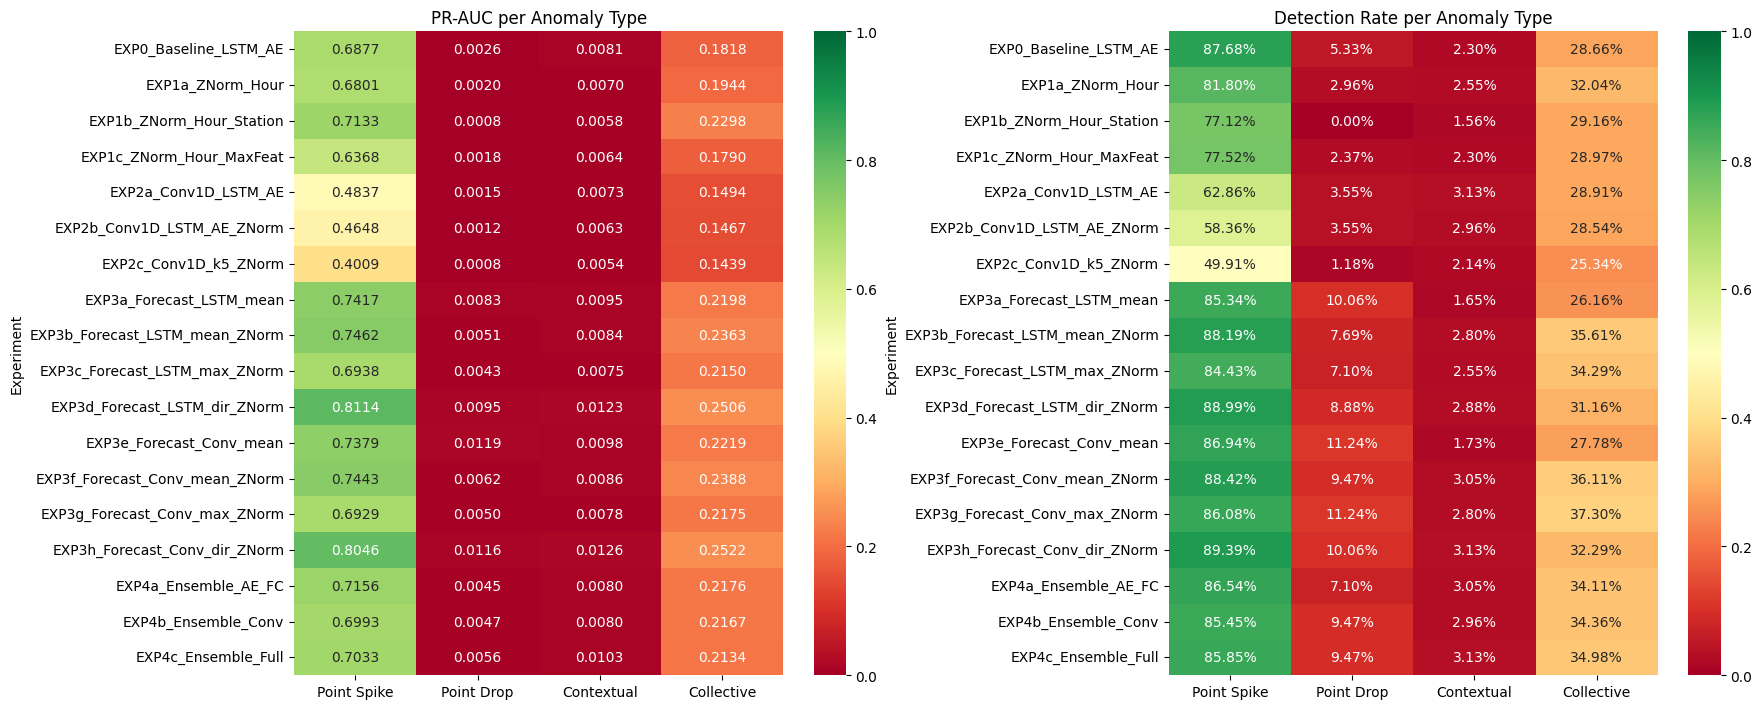

In [37]:
# ══════════════════════════════════════════════════════════════
# 34 — Heatmap: PR-AUC per Type x Experiment
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_compare)*0.4)))

# PR-AUC Heatmap
pr_data = df_compare.set_index("Experiment")[["PR_spike", "PR_drop", "PR_ctx", "PR_coll"]]
pr_data.columns = ["Point Spike", "Point Drop", "Contextual", "Collective"]
sns.heatmap(pr_data.astype(float), annot=True, fmt=".4f", cmap="RdYlGn",
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("PR-AUC per Anomaly Type")

# DR Heatmap
dr_data = df_compare.set_index("Experiment")[["DR_spike", "DR_drop", "DR_ctx", "DR_coll"]]
dr_data.columns = ["Point Spike", "Point Drop", "Contextual", "Collective"]
sns.heatmap(dr_data.astype(float), annot=True, fmt=".2%", cmap="RdYlGn",
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Detection Rate per Anomaly Type")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/v17_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


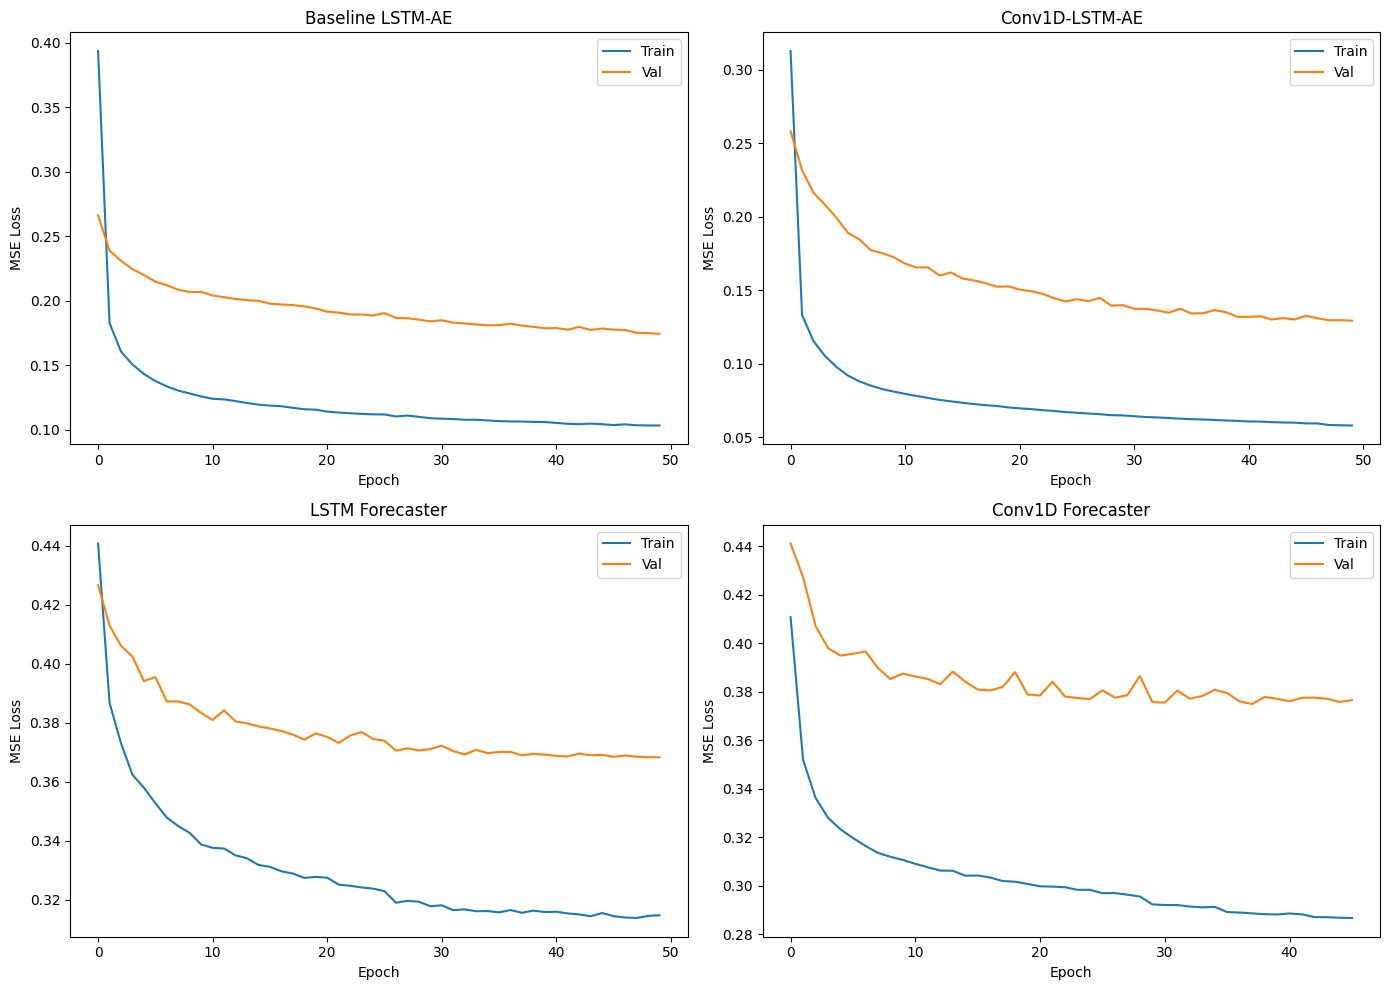

In [38]:
# ══════════════════════════════════════════════════════════════
# 35 — Training Curves Vergleich
# ══════════════════════════════════════════════════════════════


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

histories = [
    ("Baseline LSTM-AE", hist_baseline),
    ("Conv1D-LSTM-AE", hist_conv1d),
    ("LSTM Forecaster", hist_fc),
    ("Conv1D Forecaster", hist_conv_fc),
]

for ax, (name, hist) in zip(axes.flat, histories):
    ax.plot(hist.history["loss"], label="Train")
    ax.plot(hist.history["val_loss"], label="Val")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()

plt.tight_layout()
plt.show()


---
## Modelle + Artefakte speichern

In [39]:
# ══════════════════════════════════════════════════════════════
# 36 — Alle Artefakte speichern fuer Transfer-Experimente
# ══════════════════════════════════════════════════════════════
import pickle

# Scaler
with open(f"{MODELS_DIR}/scaler_mannheim.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Config
with open(f"{MODELS_DIR}/v17_config.json", "w") as f:
    json.dump(asdict(cfg), f, indent=2, default=str)

# Z-Norm Stats (fuer Transfer: diese Stats koennen auf neuer Stadt neu berechnet werden)
znorm_stats = {"mu_per_hour": mu_h, "std_per_hour": std_h}
with open(f"{MODELS_DIR}/znorm_stats_mannheim.pkl", "wb") as f:
    pickle.dump(znorm_stats, f)

# Meta mit allen Scores (fuer spaetere Analyse)
meta_save_cols = [
    "station_id", "hour_ts", "synth_label", "synth_type", "demand_regime",
    "n_lends", "n_returns", "total_demand",
    "score_baseline", "score_znorm_hour", "score_znorm_hour_station",
    "score_conv1d", "score_conv1d_znorm",
    "score_forecast", "score_forecast_znorm", "score_forecast_dir_znorm",
    "score_conv_fc", "score_conv_fc_znorm", "score_conv_fc_dir_znorm",
    "score_ensemble_ae_fc", "score_ensemble_conv", "score_ensemble_full",
    "split_eval"
]
meta_save = meta_all[[c for c in meta_save_cols if c in meta_all.columns]].copy()
meta_save.to_parquet(f"{RESULTS_DIR}/v17_meta_all_scores.parquet", index=False)

# Summary
print("=== GESPEICHERTE ARTEFAKTE ===")
for f in glob.glob(f"{MODELS_DIR}/*"):
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {os.path.basename(f):40s} {size_mb:6.1f} MB")
for f in glob.glob(f"{RESULTS_DIR}/*.parquet") + glob.glob(f"{RESULTS_DIR}/*.csv"):
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {os.path.basename(f):40s} {size_mb:6.1f} MB")


=== GESPEICHERTE ARTEFAKTE ===
  baseline_lstm_ae.keras                      0.4 MB
  conv1d_lstm_ae.keras                        0.5 MB
  conv1d_lstm_ae_k5.keras                     0.6 MB
  lstm_forecaster.keras                       0.2 MB
  conv1d_lstm_forecaster.keras                0.2 MB
  scaler_mannheim.pkl                         0.0 MB
  v17_config.json                             0.0 MB
  znorm_stats_mannheim.pkl                    0.0 MB
  v17_meta_all_scores.parquet               135.2 MB
  v17_comparison.csv                          0.0 MB


---
## Fazit / Naechste Schritte

### Fuer Transfer relevant:
- **Conv1D-Filter** lernen stadtunabhaengige lokale Muster → transferiert gut
- **Z-Normalisierung** muss pro Stadt neu kalibriert werden (auf Target-VAL)
- **Forecaster** braucht keine stadtspezifische Reconstruction-Verteilung
- **Ensemble** kann modular zusammengesetzt werden: AE von Source, Stat von Target

### Gespeicherte Modelle:
1. `baseline_lstm_ae.keras` — Referenzmodell
2. `conv1d_lstm_ae.keras` — Transfer-Kandidat #1
3. `conv1d_lstm_ae_k5.keras` — Transfer-Kandidat #2
4. `lstm_forecaster.keras` — Transfer-Kandidat #3
5. `conv1d_lstm_forecaster.keras` — Transfer-Kandidat #4
6. `scaler_mannheim.pkl` — Source-Scaler
7. `v17_config.json` — Reproduzierbare Config
